### Q) Aim is to train the regression model for predicting the house prices in goregoan city 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv(r"c:\Users\Admin\Downloads\house_cleaned.csv",encoding='Latin')

In [3]:
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,5 Bedroom House for sale in Sector 70A Gurgaon,house,bptp visionnaire,5.25,20115.0,2610.0,Plot area 290(242.48 sq.m.),5,4,3+,servant room,"29b, Sector 70A Gurgaon, Gurgaon, Haryana",3.0,North-East,0 to 1 Year Old,"['Good Earth City Center 2', 'Kunskapsskolan I...",Do you wish to buy an independent house in sec...,"['1 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Ge...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment5 out of 5', 'Lifestyle4 out of 5..."
1,5 Bedroom House for sale in Sector 21A Faridabad,house,independent,5.70,105751.0,539.0,Plot area 539(50.07 sq.m.),5,4,2,"store room,pooja room,servant room","Sector 21A Faridabad, Gurgaon, Haryana",2.0,NaN,5 to 10 Year Old,NaN,"Hi, we have an independent house/villa availab...","['1 Water Purifier', '5 Fan', '1 Exhaust Fan',...","['Private Garden / Terrace', 'Park', 'Visitor ...",NaN
2,10 Bedroom House for sale in Sushant Lok Phase 1,house,independent,2.10,38251.0,549.0,Plot area 61(51 sq.m.),10,10,3+,servant room,"Sushant Lok Phase 1, Gurgaon, Haryana",5.0,West,0 to 1 Year Old,"['Sector 42-43 metro station', 'Huda city cent...","Monthly rental income is rs1,40,000/- Best opt...","['10 Bed', '3 Fan', '10 Geyser', '2 Light', 'N...","['Maintenance Staff', 'Water Storage', 'Visito...","['Environment5 out of 5', 'Lifestyle5 out of 5..."
3,21 Bedroom House for sale in Sector 54 Gurgaon,house,independent,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,servant room,"Sector 54 Gurgaon, Gurgaon, Haryana",5.0,North,1 to 5 Year Old,"['Sector 53-54 metro station', 'Sector 54 chow...","129 sq yd plot size. 5 floors built up , fully...","['1 Water Purifier', '21 Fan', '1 Fridge', '1 ...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment4 out of 5', 'Lifestyle5 out of 5..."
4,12 Bedroom House for sale in Sushant Lok Phase 1,house,independent,3.00,53763.0,558.0,Plot area 62(51.84 sq.m.),12,12,3+,others,"1228, Sushant Lok Phase 1, Gurgaon, Haryana",5.0,West,Within 6 months,"['Sector 42-43 metro station', 'Huda city cent...",Best for investment purpose. Fully furnished b...,"['1 Water Purifier', '1 Fridge', '12 Fan', '1 ...","['Maintenance Staff', 'Water Storage', 'Visito...","['Environment5 out of 5', 'Lifestyle5 out of 5..."


In [4]:
# All are house only no patter formation we will drop it !!
df['property_type'].value_counts()

property_type
house    964
Name: count, dtype: int64

In [5]:
df['address'].value_counts()

address
DLF Phase 1, Gurgaon, Haryana                                                                                                              17
Nirvana Country, Gurgaon, Haryana                                                                                                          15
Palam Vihar, Gurgaon, Haryana                                                                                                              14
DLF Phase 2, Gurgaon, Haryana                                                                                                              13
Sector 48 Gurgaon, Gurgaon, Haryana                                                                                                        13
                                                                                                                                           ..
Iffco Chowk, Sector 17 Gurgaon, Gurgaon, Haryana                                                                                            

In [6]:
print(type(df['address'].iloc[0]))

<class 'str'>


## Extracting Address into a meaningfull catagories

In [7]:
df['address'].unique()

array(['29b, Sector 70A Gurgaon, Gurgaon, Haryana',
       'Sector 21A Faridabad, Gurgaon, Haryana',
       'Sushant Lok Phase 1, Gurgaon, Haryana',
       'Sector 54 Gurgaon, Gurgaon, Haryana',
       '1228, Sushant Lok Phase 1, Gurgaon, Haryana',
       'Sector 66 Gurgaon, Gurgaon, Haryana',
       'DLF Phase 1, Gurgaon, Haryana', 'DLF Phase 2, Gurgaon, Haryana',
       'C Block Small Nos, Sushant Lok Phase 1, Gurgaon, Haryana',
       '001, DLF Phase 2, Gurgaon, Haryana',
       'Near Galleria, DLF Phase 4, Gurgaon, Haryana',
       'Dlf Phase 3, DLF Phase 3, Gurgaon, Haryana',
       'A Block, DLF Phase 1, Gurgaon, Haryana',
       'Sushant Lok, B Block Sushant Lok Phase 1, Gurgaon, Haryana',
       'New Palam Vihar Phase 1, Gurgaon, Haryana',
       'Sector 38 Gurgaon, Gurgaon, Haryana',
       'Nirvana Country, Gurgaon, Haryana',
       'Uppals Southend, Gurgaon, Haryana',
       'Sector 9 Gurgaon, Gurgaon, Haryana',
       'Sector 48 Gurgaon, Gurgaon, Haryana',
       '2/22, DLF

In [8]:
import re

def extract_location(x):
    if not isinstance(x, str):
        return "other"
    
    x = x.lower()
    
    patterns = [
        r'dlf phase \d+',
        r'sushant lok phase \d+',
        r'sushant lok',
        r'palam vihar',
        r'nirvana country',
        r'sector \d+',
        r'iffco chowk',
        r'greenwood city',
        r'sohna road',
        r'mg road',
        r'cyber city',
        r'golf course road',
        r'udaI nagar',
    ]
    
    for pattern in patterns:
        match = re.search(pattern, x)
        if match:
            return match.group()
    
    return "rare"

In [9]:
df['location']=df['address'].apply(extract_location)

In [10]:
df['location'].value_counts()

location
rare                   263
dlf phase 1             43
sushant lok phase 1     41
dlf phase 2             39
sector 109              38
                      ... 
sector 61                1
sector 42                1
sector 83                1
sector 73                1
sector 106               1
Name: count, Length: 87, dtype: int64

In [11]:
# grouping location and their corresponding priceses
loc_price = df.groupby('location')['price'].mean().sort_values(ascending=False)
loc_price

location
sector 60      18.020000
sector 73      17.000000
dlf phase 1    13.852093
sector 66      12.662308
sector 65      12.500000
                 ...    
sector 36       0.753333
sector 6        0.750000
sector 8        0.560000
iffco chowk     0.380000
sector 110      0.340000
Name: price, Length: 87, dtype: float64

## applying target encoding 
- on location col 

In [12]:
df['location_target']=df['location'].map(loc_price)

In [13]:
df['location_target']

0       3.711429
1       5.700000
2       6.874146
3      11.728571
4       6.874146
         ...    
959     5.485714
960     9.309730
961     5.485714
962     5.485714
963     1.945792
Name: location_target, Length: 964, dtype: float64

In [14]:
# luxary tag 
luxury_locs = [
    'golf course road',
    'dlf phase 1',
    'dlf phase 2',
    'dlf phase 4',
    'nirvana country',
    'sushant lok',
    'sector 66'
]

df['is_premium_loc'] = df['location'].apply(lambda x: 1 if x in luxury_locs else 0)

In [15]:
df['is_premium_loc'].value_counts()

is_premium_loc
0    819
1    145
Name: count, dtype: int64

In [16]:
df['is_rare']=df['location'].apply(lambda x : 1 if x =='rare' else 0)

In [17]:
df['is_rare'].value_counts()

is_rare
0    701
1    263
Name: count, dtype: int64

In [18]:
# those who are not rare shows high price 
df.groupby('is_rare')['price'].mean().sort_values(ascending=False)

is_rare
0    6.030612
1    1.945792
Name: price, dtype: float64

In [19]:
df.groupby('is_premium_loc')['price'].mean().sort_values(ascending=False)

is_premium_loc
1    10.979781
0     3.882092
Name: price, dtype: float64

In [20]:
df.drop(columns=['address','location'],axis=1,inplace=True)

In [21]:
df.columns

Index(['property_name', 'property_type', 'society', 'price', 'price_per_sqft',
       'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony',
       'additionalRoom', 'floorNum', 'facing', 'agePossession',
       'nearbyLocations', 'description', 'furnishDetails', 'features',
       'rating', 'location_target', 'is_premium_loc', 'is_rare'],
      dtype='object')

# Area with type :

In [22]:
df['areaWithType'].value_counts()

areaWithType
Plot area 360(301.01 sq.m.)                                                                                      38
Plot area 300(250.84 sq.m.)                                                                                      27
Plot area 200(167.23 sq.m.)                                                                                      20
Plot area 270(225.75 sq.m.)                                                                                      19
Plot area 502(419.74 sq.m.)                                                                                      19
                                                                                                                 ..
Plot area 5400(501.68 sq.m.)                                                                                      1
Plot area 220Built Up area: 170 sq.m.Carpet area: 160 sq.m.                                                       1
Plot area 384(321.07 sq.m.)                                

 Extract the plot area in sq m 

In [23]:
import re 
def extract_plot_area(x):
    match = re.search(r'\(([\d.]+)\s*sq\.m',str(x))
    if match:
        return float(match.group(1))
    return None

df['plot_area_sqm']=df['areaWithType'].apply(extract_plot_area)

In [24]:
df['plot_area_sqm'] # plot area in sqm m 

0      242.48
1       50.07
2       51.00
3      107.86
4       51.84
        ...  
959    167.23
960    125.42
961    125.42
962     91.14
963    225.75
Name: plot_area_sqm, Length: 964, dtype: float64

In [25]:
df['plot_area_sqm'].isnull().sum()

np.int64(9)

In [26]:
df['plot_area_sqm'].skew()

np.float64(30.892724498462982)

In [27]:
df['plot_area_sqm'].fillna(df['plot_area_sqm'].median(),inplace=True)

In [28]:
df['plot_area_sqm'].isnull().sum()

np.int64(0)

In [29]:
df.groupby('plot_area_sqm')['price'].mean()

plot_area_sqm
4.18          0.65
4.65          0.43
5.02          0.75
5.11          0.50
5.20          0.55
             ...  
2591.99       6.25
4699.04       5.50
6061.92      13.00
7692.86       1.25
809372.00     1.45
Name: price, Length: 345, dtype: float64

Extract the Carpet area 

In [30]:
def extract_carpet(x):
    match = re.search(r'Carpet\s*area.*?\(?([\d.]+)\s*sq\.m', str(x), re.IGNORECASE)
    if match:
        return float(match.group(1))
    return None

df['carpet_area_sqm'] = df['areaWithType'].apply(extract_carpet)

In [31]:
df['carpet_area_sqm'].value_counts().sum()

np.int64(184)

Extract the build up area 

In [32]:
def extract_builtup(x):
    match = re.search(r'Built\s*Up\s*area.*?\(?([\d.]+)\s*sq\.m', str(x), re.IGNORECASE)
    if match:
        return float(match.group(1))
    return None

df['builtup_area_sqm'] = df['areaWithType'].apply(extract_builtup)

In [33]:
df['builtup_area_sqm'].value_counts().sum()

np.int64(288)

Build Net effective area 

In [34]:
df['effective_area']=(df['carpet_area_sqm'].fillna(df['builtup_area_sqm']).fillna(df['plot_area_sqm']))

In [35]:
df['effective_area'] # is the combination of carpet , buildup , plot area 

0      242.48
1       50.07
2       51.00
3      107.86
4       51.84
        ...  
959    167.23
960    125.42
961    125.42
962     91.14
963    225.75
Name: effective_area, Length: 964, dtype: float64

In [36]:
df['effective_area'].corr(df['price'])

np.float64(-0.01864998322314979)

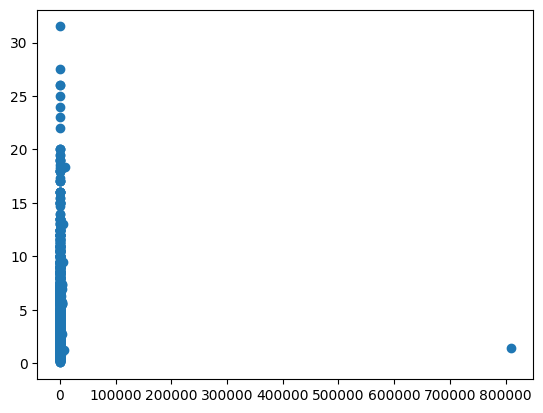

In [37]:
plt.scatter(x='effective_area',y='price',data=df) # extreme noise high outliers 

In [38]:
df[df['effective_area']<3483.726200000002].shape # 10 are heavy outliers 

(954, 26)

In [39]:
df = df[df['effective_area'] < df['effective_area'].quantile(0.99)]

In [40]:
df['effective_area_log'] = np.log1p(df['effective_area'])

<Axes: xlabel='effective_area_log', ylabel='Count'>

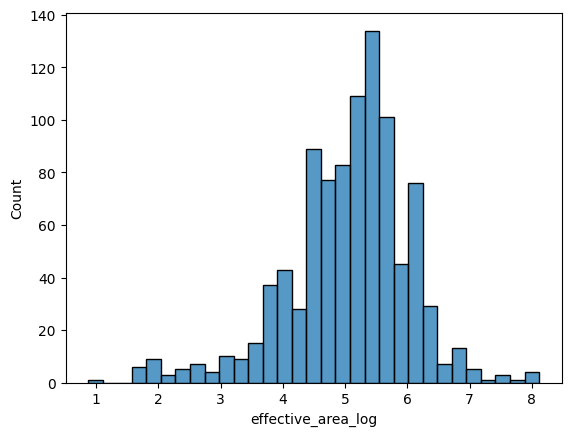

In [41]:
sns.histplot(df['effective_area_log'])

In [42]:
df['effective_area_log'].corr(df['price']) # high corr with price

np.float64(0.5579984737928829)

In [43]:
# to check the area of with type (carpet,builtup,plot)
df['area_quality'] = np.select(
    [
        df['carpet_area_sqm'].notna(),
        df['builtup_area_sqm'].notna(),
        df['plot_area_sqm'].notna()
    ],
    [3, 2, 1],
    default=0
)

In [44]:
df['area_quality'].value_counts()

area_quality
1    615
3    179
2    160
Name: count, dtype: int64

In [45]:
df[['effective_area_log','area_quality']]

,effective_area_log,area_quality
0,5.495035,1
1,3.933197,1
2,3.951244,1
3,4.690063,1
4,3.967268,1
...,...,...
959,5.125332,1
960,4.839610,1
961,4.839610,1
962,4.523309,1


Text(0, 0.5, 'price')

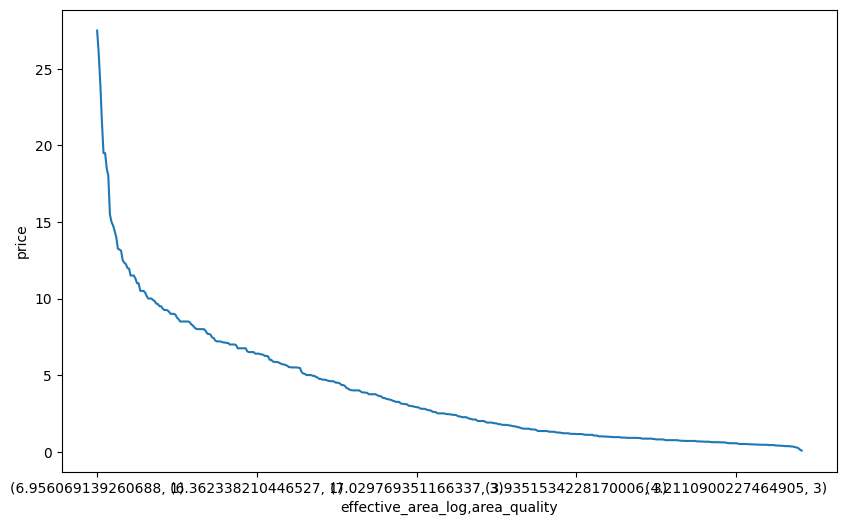

In [46]:
plt.figure(figsize=(10,6))
df.groupby(['effective_area_log','area_quality'])['price'].mean().sort_values(ascending=False).plot()
plt.ylabel('price')

we can see price depends on area, area quality 

### creating feature carpet efficency 
- higher the carpet efficiency higher is the carpet area and vice versa 

In [47]:
df['carpet_efficiency']=df['carpet_area_sqm']/df['builtup_area_sqm']

### creating feature buildup to plot ratio
- higher the construction density , means heavy construction less land remaining 

In [48]:
df['construction_density'] = df['builtup_area_sqm'] / df['plot_area_sqm']

In [49]:
# setting up a flag to let the model aware about missing values 
df['carpet_eff_missing'] = df['carpet_efficiency'].isna().astype(int) 

In [50]:
df['carpet_eff_missing'].value_counts()

carpet_eff_missing
1    832
0    122
Name: count, dtype: int64

In [51]:
# df.groupby(df['construction_density'].isna())['price'].mean()

In [52]:
df['construction_dens_missing'] = df['construction_density'].isna().astype(int)

In [53]:
df['carpet_efficiency'] = df['carpet_efficiency'].fillna(df['carpet_efficiency'].median())
df['construction_density'] = df['construction_density'].fillna(df['construction_density'].median())

In [54]:
df['carpet_efficiency'].value_counts()

carpet_efficiency
0.888885    832
0.899958      2
0.937509      2
0.777731      2
0.973657      2
           ... 
0.888890      1
0.833355      1
0.869579      1
0.791671      1
0.970558      1
Name: count, Length: 119, dtype: int64

In [55]:
df['carpet_efficiency'].corr(df['price']) # shows strong corr with price 

np.float64(0.044105274515575194)

In [ ]:
df['construction_density'].corr(df['price']) # hence constn density show 0 corr with price

np.float64(-0.015873406940411932)

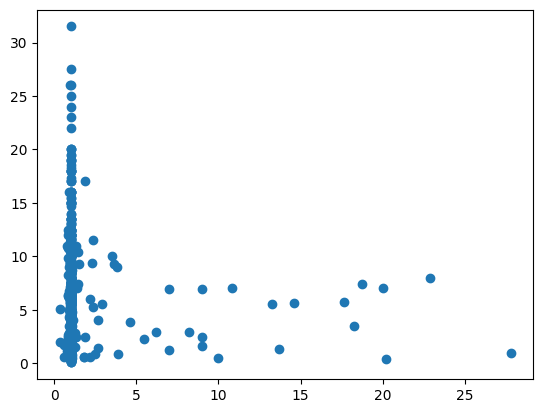

In [57]:
plt.scatter(df['construction_density'], df['price'])

created new interactive feature desity x area 

In [58]:
df['density_x_area'] = df['construction_density'] * df['effective_area']

In [59]:
df['density_x_area'].corr(df['price'])

np.float64(0.04311187976998794)

In [60]:
df.drop(['effective_area'],axis=1,inplace=True)

In [61]:
df.drop(columns=['areaWithType','plot_area_sqm','builtup_area_sqm','carpet_area_sqm','construction_density'],axis=1,inplace=True)

In [62]:
df.columns

Index(['property_name', 'property_type', 'society', 'price', 'price_per_sqft',
       'area', 'bedRoom', 'bathroom', 'balcony', 'additionalRoom', 'floorNum',
       'facing', 'agePossession', 'nearbyLocations', 'description',
       'furnishDetails', 'features', 'rating', 'location_target',
       'is_premium_loc', 'is_rare', 'effective_area_log', 'area_quality',
       'carpet_efficiency', 'carpet_eff_missing', 'construction_dens_missing',
       'density_x_area'],
      dtype='object')

## society 


In [63]:
df['society'].value_counts()

society
independent                            565
vipul tatvam villa                      19
international city by sobha phase 2     19
emaar mgf marbella                      16
international city by sobha phase 1     15
                                      ... 
godrej meridien                          1
sector 57 huda                           1
saksham welfare association              1
huda                                     1
huda floor                               1
Name: count, Length: 177, dtype: int64

In [64]:
society_counts = df['society'].value_counts()

df['society'] = df['society'].apply(lambda x: x if society_counts[x] > 5 else 'rare')

In [65]:
df['society'].value_counts()

society
independent                            565
rare                                   240
vipul tatvam villa                      19
international city by sobha phase 2     19
emaar mgf marbella                      16
international city by sobha phase 1     15
unitech uniworld resorts                13
dlf city plots                          11
unitech espace                          11
dlf city plots phase 2                  11
bptp visionnaire                         8
not applicable                           7
uppal southend                           7
sushant lok 1 builder floors             6
eldeco mansionz                          6
Name: count, dtype: int64

In [66]:
society_freq = df['society'].value_counts()
df['society_encoded']=df['society'].map(lambda x : 1/society_freq[x]) # by reversing higher values get converted to lower values to preserve the meaning 

In [67]:
df['society_encoded']

0      0.125000
1      0.001770
2      0.001770
3      0.001770
4      0.001770
         ...   
959    0.004167
960    0.090909
961    0.004167
962    0.004167
963    0.004167
Name: society_encoded, Length: 954, dtype: float64

In [68]:
df['society_encoded'].corr(df['price'])

np.float64(0.24841921681738732)

In [69]:
df['society_israre']=df['society'].apply(lambda x : 1 if x =='rare' else 0)
df['is_independent']=df['society'].apply(lambda x : 1 if x =='independent' else 0)

In [70]:
df['society_israre'].value_counts()

society_israre
0    714
1    240
Name: count, dtype: int64

In [71]:
df['is_independent'].value_counts()

is_independent
1    565
0    389
Name: count, dtype: int64

In [72]:
df.drop(columns=['society'],axis=1,inplace=True)

In [73]:
df.columns

Index(['property_name', 'property_type', 'price', 'price_per_sqft', 'area',
       'bedRoom', 'bathroom', 'balcony', 'additionalRoom', 'floorNum',
       'facing', 'agePossession', 'nearbyLocations', 'description',
       'furnishDetails', 'features', 'rating', 'location_target',
       'is_premium_loc', 'is_rare', 'effective_area_log', 'area_quality',
       'carpet_efficiency', 'carpet_eff_missing', 'construction_dens_missing',
       'density_x_area', 'society_encoded', 'society_israre',
       'is_independent'],
      dtype='object')

# floorNum

In [74]:
df['floorNum'].value_counts()

floorNum
3.0     298
2.0     287
1.0     180
4.0     135
5.0       9
0.0       6
14.0      3
6.0       3
12.0      2
10.0      2
11.0      2
13.0      1
27.0      1
21.0      1
20.0      1
41.0      1
51.0      1
16.0      1
33.0      1
Name: count, dtype: int64

In [75]:
valid_floors = df['floorNum'].value_counts()
valid_floors = valid_floors[valid_floors >=10].index

df['floorNum']=df['floorNum'].where(df['floorNum'].isin (valid_floors) , 'other')
df['floorNum'].value_counts()


floorNum
3.0      298
2.0      287
1.0      180
4.0      135
other     54
Name: count, dtype: int64

In [76]:
df['floorNum'] = df['floorNum'].replace('other', 20)
df['floorNum'] = df['floorNum'].astype(float)
df['floorNum'].value_counts()


C:\Users\Admin\AppData\Local\Temp\ipykernel_19948\2989497573.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['floorNum'] = df['floorNum'].replace('other', 20)


floorNum
3.0     298
2.0     287
1.0     180
4.0     135
20.0     54
Name: count, dtype: int64

In [77]:

df['floorNum'].skew()

np.float64(3.5150780762272515)

<Axes: xlabel='floorNum', ylabel='Count'>

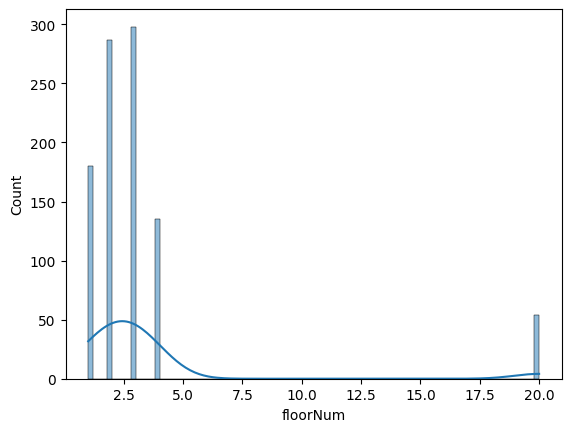

In [78]:
sns.histplot(df['floorNum'],kde=True)

<Axes: ylabel='floorNum'>

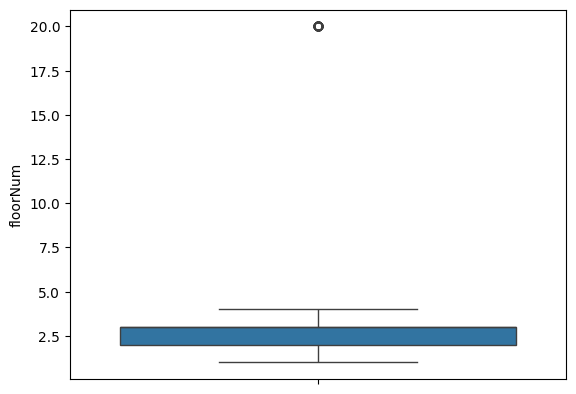

In [79]:
sns.boxplot(df['floorNum'])

#### Apply transformation to make the data normally distributed / gausion 

In [80]:
from sklearn.preprocessing import PowerTransformer
pi = PowerTransformer()
df['floorNum']=pi.fit_transform(df[['floorNum']])

-0.01148550681211627

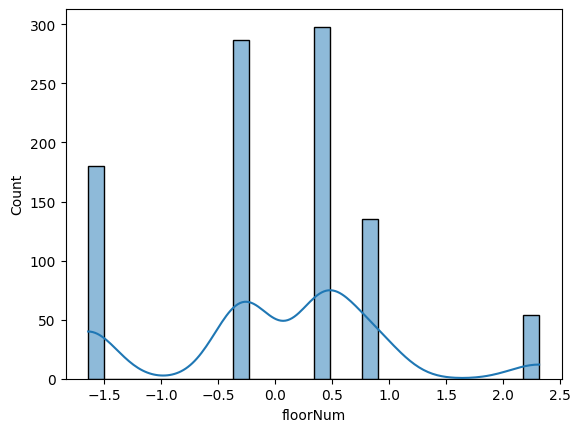

In [81]:
sns.histplot(df['floorNum'],kde=True)
df['floorNum'].skew().item() # col get normal distributed 

#### as the data became normally distributed , we will applt z score outlier detection method , and cap it 

<Axes: ylabel='floorNum'>

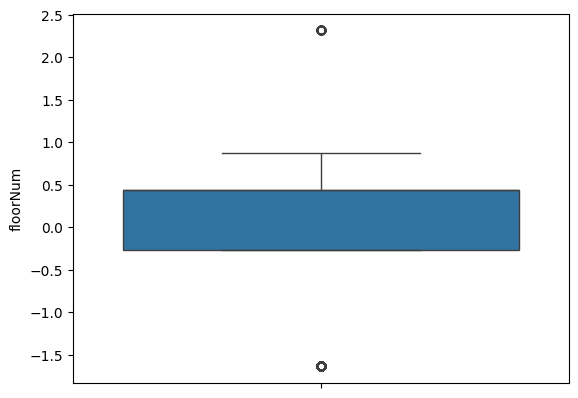

In [82]:
sns.boxplot(df['floorNum'])

In [83]:
print('Mean value of floor :',df['floorNum'].mean())
print('std value of floors :',df['floorNum'].std())

Mean value of floor : -1.3406466712454721e-15
std value of floors : 1.0005245214103133


In [84]:
# Finding the boundary values 
print('highest floor boundary :', df['floorNum'].mean() + 3*df['floorNum'].std())
print('lowest floor boundary  :', df['floorNum'].mean() - 3*df['floorNum'].std())

highest floor boundary : 3.0015735642309385
lowest floor boundary  : -3.001573564230941


In [85]:
# Outliers 
df[(df['floorNum'] > 3) | (df['floorNum']<-3)]

,property_name,property_type,price,price_per_sqft,area,bedRoom,bathroom,balcony,additionalRoom,floorNum,...,is_rare,effective_area_log,area_quality,carpet_efficiency,carpet_eff_missing,construction_dens_missing,density_x_area,society_encoded,society_israre,is_independent


### hence there is no such valus present outside the desired boundaries , hence no outliers present 

In [86]:
df['floorNum'].corr(df['price'])

np.float64(0.17394844869198922)

In [87]:
df.drop(['property_name','property_type','description'],axis=1,inplace=True)

In [88]:
df.shape

(954, 26)

In [89]:
df.head(1)

,price,price_per_sqft,area,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,...,is_rare,effective_area_log,area_quality,carpet_efficiency,carpet_eff_missing,construction_dens_missing,density_x_area,society_encoded,society_israre,is_independent
0,5.25,20115.0,2610.0,5,4,3+,servant room,0.436526,North-East,0 to 1 Year Old,...,0,5.495035,1,0.888885,1,1,242.48,0.125,0,0


In [90]:
df['balcony']=df['balcony'].replace({'3+':3})

Text(0, 0.5, 'No of houses')

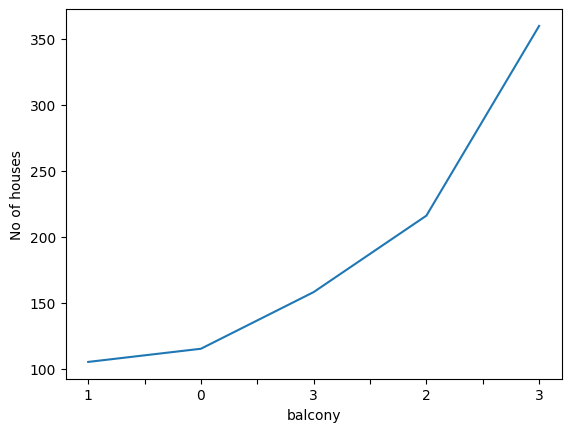

In [91]:
df['balcony'].value_counts().sort_values(ascending=True).plot()
plt.ylabel('No of houses')

In [92]:
df['additionalRoom'].value_counts()# it is a  multi-labeled categorical data 

additionalRoom
not available                                    384
servant room                                      80
pooja room,study room,servant room,store room     59
others                                            57
pooja room                                        36
pooja room,study room,servant room                33
pooja room,study room,servant room,others         32
store room                                        31
pooja room,servant room                           24
study room                                        19
study room,servant room                           19
servant room,store room                           14
pooja room,others                                 11
pooja room,store room                             11
pooja room,study room                             10
pooja room,store room,study room,servant room      8
servant room,others                                8
servant room,pooja room                            8
pooja room,servant room,store r

<Axes: xlabel='additionalRoom'>

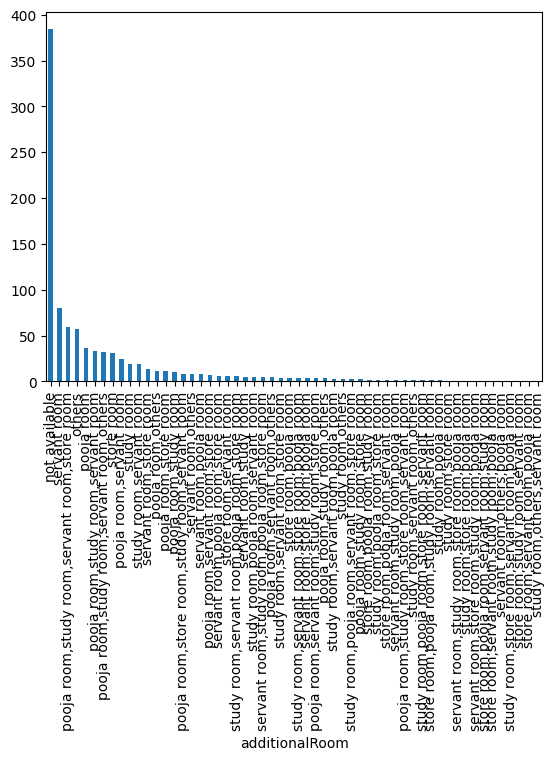

In [93]:
df['additionalRoom'].value_counts().sort_values(ascending=False).plot.bar()

most of the houses has no additional rooms available 

create binary fetures 

In [94]:
df['servant_room'] = df['additionalRoom'].apply(lambda x: 1 if 'servant room' in x else 0)
df['pooja_room'] = df['additionalRoom'].apply(lambda x: 1 if 'pooja room' in x else 0)
df['study_room'] = df['additionalRoom'].apply(lambda x: 1 if 'study room' in x else 0)
df['store_room'] = df['additionalRoom'].apply(lambda x: 1 if 'store room' in x else 0)

In [95]:
df['Total_extra_rooms'] = (
    df['servant_room'] +
    df['pooja_room'] +
    df['study_room'] +
    df['store_room']
)

In [96]:
df['Total_extra_rooms']

0      1
1      3
2      1
3      1
4      0
      ..
959    3
960    1
961    2
962    1
963    3
Name: Total_extra_rooms, Length: 954, dtype: int64

In [97]:
df['Total_extra_rooms'].corr(df['price']) # this shows heavy corr with the price 

np.float64(0.5713084009212376)

In [98]:
df['no_extra_room']=df['additionalRoom'].apply(lambda x : 1 if x =='not available' else 0)

In [99]:
df['no_extra_room'].value_counts()

no_extra_room
0    570
1    384
Name: count, dtype: int64

In [100]:
Rooms=[
    'servant_room',
    'pooja_room',
    'study_room',
    'store_room'
]
for room in Rooms :
    ans = df.groupby(room)['price'].mean()    # hence this shows the clear diff in price  
    print(ans)

servant_room
0    2.709023
1    8.330138
Name: price, dtype: float64
pooja_room
0    3.580740
1    7.480541
Name: price, dtype: float64
study_room
0    3.705660
1    8.189919
Name: price, dtype: float64
store_room
0    4.110000
1    7.830153
Name: price, dtype: float64


In [101]:
df.drop(['additionalRoom'],axis=1,inplace=True)

In [102]:
df.columns

Index(['price', 'price_per_sqft', 'area', 'bedRoom', 'bathroom', 'balcony',
       'floorNum', 'facing', 'agePossession', 'nearbyLocations',
       'furnishDetails', 'features', 'rating', 'location_target',
       'is_premium_loc', 'is_rare', 'effective_area_log', 'area_quality',
       'carpet_efficiency', 'carpet_eff_missing', 'construction_dens_missing',
       'density_x_area', 'society_encoded', 'society_israre', 'is_independent',
       'servant_room', 'pooja_room', 'study_room', 'store_room',
       'Total_extra_rooms', 'no_extra_room'],
      dtype='object')

In [103]:
df.shape

(954, 31)

In [104]:
df['agePossession'].value_counts()  

agePossession
5 to 10 Year Old      249
1 to 5 Year Old       222
10+ Year Old          214
undefined             141
0 to 1 Year Old       108
Within 6 months         7
Jun 2024                2
Dec 2023                2
Under Construction      2
By 2027                 1
Oct 2024                1
By 2024                 1
Dec 2024                1
Within 3 months         1
Oct 2023                1
Jan 2024                1
Name: count, dtype: int64

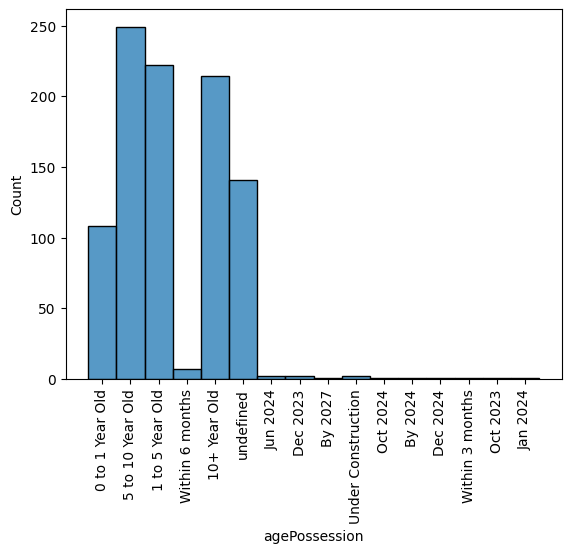

In [105]:
sns.histplot(df['agePossession'])
plt.xticks(rotation=90)
plt.show()

distributation of houses per year 

<Axes: xlabel='agePossession'>

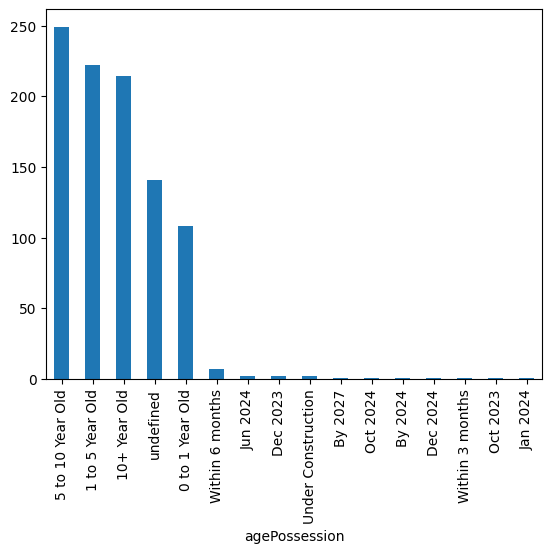

In [106]:
df['agePossession'].value_counts().sort_values(ascending=False).plot.bar()

In [107]:
valid_catagories = df['agePossession'].value_counts()
valid_catagories = valid_catagories[valid_catagories >=10].index

df['agePossession']= df['agePossession'].where(df['agePossession'].isin(valid_catagories) ,'Other')
df['agePossession'].value_counts()

agePossession
5 to 10 Year Old    249
1 to 5 Year Old     222
10+ Year Old        214
undefined           141
0 to 1 Year Old     108
Other                20
Name: count, dtype: int64

### applying numeric approximation on feature 

In [108]:
mapping = {
    'Within 6 months': 0.25,
    '0 to 1 Year Old': 0.5,
    '1 to 5 Year Old': 3,
    
    '5 to 10 Year Old': 7.5,
    '10+ Year Old': 12,
    'undefined': np.nan,
    'Other': np.nan
}
df['agePossession_num'] = df['agePossession'].map(mapping)
df['agePossession_num'].value_counts()

agePossession_num
7.5     249
3.0     222
12.0    214
0.5     108
Name: count, dtype: int64

In [109]:
df['agePossession_num'].fillna(df['agePossession_num'].median(),inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19948\1237048532.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['agePossession_num'].fillna(df['agePossession_num'].median(),inplace=True)


In [110]:
df['agePossession_num'].isnull().sum()

np.int64(0)

<Axes: xlabel='agePossession_num', ylabel='Count'>

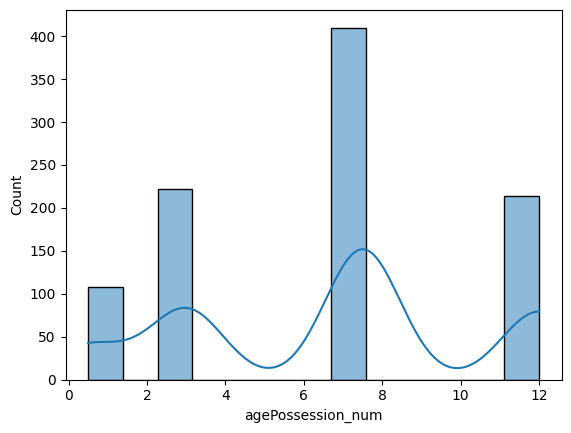

In [111]:
sns.histplot(df['agePossession_num'],kde=True)

In [112]:
df['agePossession_num'].skew() # symmetric distributation 

np.float64(-0.07317899491953649)

In [113]:
df.drop(columns=['agePossession'],inplace=True)

In [114]:
df.columns

Index(['price', 'price_per_sqft', 'area', 'bedRoom', 'bathroom', 'balcony',
       'floorNum', 'facing', 'nearbyLocations', 'furnishDetails', 'features',
       'rating', 'location_target', 'is_premium_loc', 'is_rare',
       'effective_area_log', 'area_quality', 'carpet_efficiency',
       'carpet_eff_missing', 'construction_dens_missing', 'density_x_area',
       'society_encoded', 'society_israre', 'is_independent', 'servant_room',
       'pooja_room', 'study_room', 'store_room', 'Total_extra_rooms',
       'no_extra_room', 'agePossession_num'],
      dtype='object')

In [115]:
df.shape

(954, 31)

In [116]:
df.head(1)

,price,price_per_sqft,area,bedRoom,bathroom,balcony,floorNum,facing,nearbyLocations,furnishDetails,...,society_encoded,society_israre,is_independent,servant_room,pooja_room,study_room,store_room,Total_extra_rooms,no_extra_room,agePossession_num
0,5.25,20115.0,2610.0,5,4,3,0.436526,North-East,"['Good Earth City Center 2', 'Kunskapsskolan I...","['1 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Ge...",...,0.125,0,0,1,0,0,0,1,0,0.5


# Nearby locations 

In [117]:
df['nearbyLocations'].value_counts()

nearbyLocations
['Guru dronacharya metro station', 'Dlf phase 1 metro station', 'Sikandarpur rmrg metro station', 'Sikanderpur metro station', 'Sikandarpur metro station', 'Dlf phase 2 metro station', 'Hanuman Mandir', 'Icici bank ATM', 'Axis bank ATM', 'Central bank ATM', 'Central bank atm teste 001112', 'Sikka Maternity And Surgical Center', 'Anahat Hospital', 'Divine Look Clinic Centre 1', 'The Dental Lounge', "St Stephen's Hospital Health Care Facility", 'Marwah Clinic', 'Durga Poly Clinic', 'Krishna Family Clinic', 'Upkar Clinic', 'Surgi Center Clinic', 'Lord Krishna Hospital', 'Uma Sanjeevani Health Centre And Hospital', 'Cosmodentz Dental Clinic', 'Kailash Nursing Home Gurgaon', "Dr. Khullar's Dental Clinic", 'Relief Physiotherapy Clinic', 'RBS Dental Clinic', 'Sidhesh Hospital Gurgaon', 'Shri Ram Memorial Hospital', 'R.N Clinic', 'Dental Cure and Care Centre', 'Religare Wellness', '98.4', 'Guardian', 'Emaar Business Park', 'Axis bank', 'Hsbc bank', 'Kotak mahindra bank', 'Hdfc 

Extract the imp aminities from  nearbylocation as new col, like : seperate the data on banks , mall , metrostation , hospital , school , cinema pvr etc house prices highly depend on such aminities 

In [118]:
df['metro']=df['nearbyLocations'].str.contains('metro',case=False,na=False).astype(int)
df['near_hospital']=df['nearbyLocations'].str.contains('hospital|clinic|medical',case=False,na=False,regex=True).astype(int)
df['near_school']=df['nearbyLocations'].str.contains('school|university|collage',case=False,na=False,regex=True).astype(int)
df['near_mall']=df['nearbyLocations'].str.contains('mall|cinema|marker|pvr',case=False,na=False,regex=True).astype(int)
df['near_bank']=df['nearbyLocations'].str.contains('bank|atm',case=False,na=False,regex=True).astype(int)

In [119]:
df.drop(columns=['nearbyLocations'],inplace=True)

In [120]:
df.columns

Index(['price', 'price_per_sqft', 'area', 'bedRoom', 'bathroom', 'balcony',
       'floorNum', 'facing', 'furnishDetails', 'features', 'rating',
       'location_target', 'is_premium_loc', 'is_rare', 'effective_area_log',
       'area_quality', 'carpet_efficiency', 'carpet_eff_missing',
       'construction_dens_missing', 'density_x_area', 'society_encoded',
       'society_israre', 'is_independent', 'servant_room', 'pooja_room',
       'study_room', 'store_room', 'Total_extra_rooms', 'no_extra_room',
       'agePossession_num', 'metro', 'near_hospital', 'near_school',
       'near_mall', 'near_bank'],
      dtype='object')

In [121]:
df['metro'].value_counts()

metro
0    592
1    362
Name: count, dtype: int64

In [122]:
df['near_hospital'].value_counts()

near_hospital
1    805
0    149
Name: count, dtype: int64

In [123]:
df['near_school'].value_counts()

near_school
1    626
0    328
Name: count, dtype: int64

# Furnished Details 

In [124]:
df['furnishDetails'].value_counts()

furnishDetails
['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']     83
[]                                                                                                                                                                                                                                                                       76
['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']       25
['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa',

we devide the house into three cat based on col furnishedDetails : 
1. furnished 
2. semifurnished
3. unfurnished 

In [125]:
print(type(df['furnishDetails'].iloc[0]))

<class 'str'>


In [126]:
# convert string list to python list using literal_eval
import ast 
def clean_list(x):
    if isinstance(x,str):
        try:
            return ast.literal_eval(x) 
        except:
            return []
    return x
df['furnishDetails']=df['furnishDetails'].apply(clean_list)


In [127]:
df['furnishDetails'].value_counts()

furnishDetails
[1 Light, No AC, No Bed, No Chimney, No Curtains, No Dining Table, No Exhaust Fan, No Fan, No Geyser, No Modular Kitchen, No Microwave, No Fridge, No Sofa, No Stove, No TV, No Wardrobe, No Washing Machine, No Water Purifier]     83
[]                                                                                                                                                                                                                                   76
[1 Wardrobe, 1 Fan, 1 Light, No AC, No Bed, No Chimney, No Curtains, No Dining Table, No Exhaust Fan, No Geyser, No Modular Kitchen, No Microwave, No Fridge, No Sofa, No Stove, No TV, No Washing Machine, No Water Purifier]       25
[1 Modular Kitchen, No AC, No Bed, No Chimney, No Curtains, No Dining Table, No Exhaust Fan, No Fan, No Geyser, No Light, No Microwave, No Fridge, No Sofa, No Stove, No TV, No Wardrobe, No Washing Machine, No Water Purifier]      4
[1 Fan, 1 Light, No AC, No Bed, No Chimney, No Curtains, 

In [128]:
print(type(df['furnishDetails'].iloc[0]))

<class 'list'>


In [129]:
def furnished_detail(items):
    if not isinstance(items, list) or len(items) == 0:
        return 'Unfurnished'
    else:
        count = 0
        for item in items:
            if not item.lower().startswith('no'):
                count += 1

        if count <= 2:
            return 'Unfurnished'
        elif count <= 6:
            return 'Semi-furnished'
        else:
            return 'Furnished'
    
df['furnish_level']=df['furnishDetails'].apply(furnished_detail)

In [130]:
df['furnish_level']

0           Furnished
1      Semi-furnished
2      Semi-furnished
3           Furnished
4           Furnished
            ...      
959       Unfurnished
960       Unfurnished
961       Unfurnished
962       Unfurnished
963         Furnished
Name: furnish_level, Length: 954, dtype: object

In [131]:
df['furnish_level'].value_counts()

furnish_level
Unfurnished       457
Furnished         277
Semi-furnished    220
Name: count, dtype: int64

<Axes: xlabel='furnish_level', ylabel='Count'>

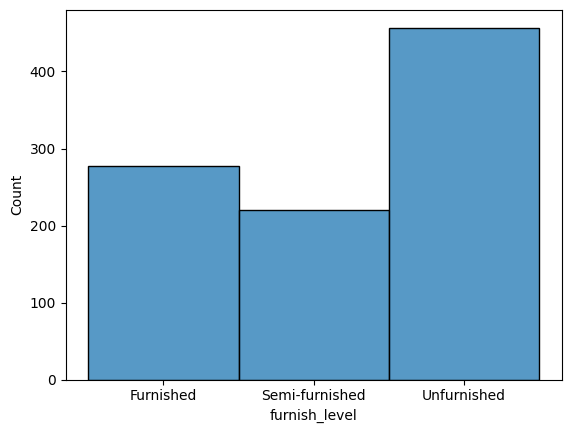

In [132]:
sns.histplot(df['furnish_level'])

we will apply ordinal encoder later on it 

In [133]:
df.groupby('furnish_level')['price'].mean() # this shows diff in mean price 

furnish_level
Furnished         7.478433
Semi-furnished    4.958028
Unfurnished       3.313422
Name: price, dtype: float64

In [134]:
df.drop(columns=['furnishDetails'],axis=1,inplace=True)

In [135]:
df.columns

Index(['price', 'price_per_sqft', 'area', 'bedRoom', 'bathroom', 'balcony',
       'floorNum', 'facing', 'features', 'rating', 'location_target',
       'is_premium_loc', 'is_rare', 'effective_area_log', 'area_quality',
       'carpet_efficiency', 'carpet_eff_missing', 'construction_dens_missing',
       'density_x_area', 'society_encoded', 'society_israre', 'is_independent',
       'servant_room', 'pooja_room', 'study_room', 'store_room',
       'Total_extra_rooms', 'no_extra_room', 'agePossession_num', 'metro',
       'near_hospital', 'near_school', 'near_mall', 'near_bank',
       'furnish_level'],
      dtype='object')

# Features

In [136]:
df['features'].value_counts()

features
['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   38
['Water Storage']                                                                                                                                                                                                                                                                                                                                                                

In [137]:
df['features'].isnull().sum()

np.int64(299)

In [138]:
type(df['features'].iloc[0])

str

In [139]:
from sklearn.impute import SimpleImputer

In [140]:
#fill fetures col 
imputer = SimpleImputer(strategy='constant',fill_value='None')
df['features']=imputer.fit_transform(df[['features']]).ravel()



In [141]:
df['features'].isnull().sum()

np.int64(0)

 features contains lots of messy data in a col , it contains str,'[]',[,dummy names which creats multiple cols of the same name each time , so now we create a func name clean list to clean the list to the python list 
 

In [142]:
import ast
def clean_list(x):
    try:
        lst = ast.literal_eval(x) # converts str list to actual python list '[]'--->[]
        return [i.strip() for i in lst]
    except: 
        return []


In [143]:
df['feature_clean']=df['features'].apply(clean_list)

In [144]:
df['feature_clean'].value_counts()

feature_clean
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   299
[Feng Shui / Vaastu Compliant, Private Garden / Terrace, Maintenance Staff, Water Storage, Park, Visitor Parking, Waste Disposal, Rain Water Harvesting]                                                                                                                                                                                                                                                                         

count the total amenities (features) in each rows 

In [145]:
df['amenity_count']=df['feature_clean'].apply(
    lambda x: len(x) if isinstance(x,list) else 0
)

In [146]:
df['amenity_count'] # this is the row wise  count of all the amenities around the house

0       8
1       6
2       4
3       8
4       4
       ..
959    13
960     6
961    11
962    12
963    25
Name: amenity_count, Length: 954, dtype: int64

In [147]:
df.groupby('amenity_count')['price'].mean() # higher the aminities higher will be the price (shows slight diff in price )

amenity_count
0      2.364576
1      2.834074
2      1.483846
3      4.212619
4      5.375435
5      5.415263
6      5.293824
7      5.683256
8      6.445417
9      5.049583
10     6.910000
11     8.198077
12     4.877333
13     8.104000
14     6.729130
15     7.145000
16     5.218750
17     8.658667
18    10.905625
19     9.942308
20     9.227895
21    11.402500
22     6.252143
23     7.601765
24     8.769130
25     7.390909
26     5.760000
27    10.234615
Name: price, dtype: float64

In [148]:
df['amenity_count'].value_counts()

amenity_count
0     299
1      55
8      49
4      47
7      44
3      43
2      39
5      39
6      34
11     26
9      24
24     23
14     23
20     19
23     17
18     17
12     17
10     16
17     15
13     15
27     14
22     14
19     13
15     12
26     11
25     11
21      9
16      9
Name: count, dtype: int64

In [149]:
df['amenity_count'].corr(df['price']) # shows heavy corr with price 

np.float64(0.48130970702272385)

In [150]:
df['zero_amenities']=df['amenity_count'].apply(lambda x : 1 if x == 0 else 0)

In [151]:
df['zero_amenities'].value_counts()

zero_amenities
0    655
1    299
Name: count, dtype: int64

In [152]:
df.groupby('zero_amenities')['price'].mean()

zero_amenities
0    6.050796
1    2.364576
Name: price, dtype: float64

<Axes: xlabel='amenity_count', ylabel='Count'>

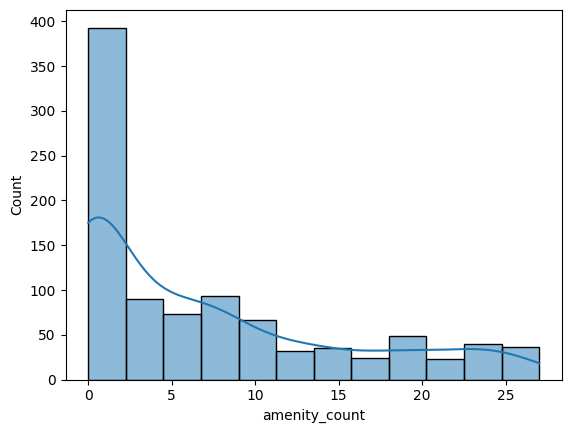

In [153]:
sns.histplot(df['amenity_count'],kde=True)

In [154]:
df.drop(columns=['feature_clean'],axis=1,inplace=True)

In [155]:
df.drop(columns=['features'],axis=1,inplace=True)

In [156]:
df.columns

Index(['price', 'price_per_sqft', 'area', 'bedRoom', 'bathroom', 'balcony',
       'floorNum', 'facing', 'rating', 'location_target', 'is_premium_loc',
       'is_rare', 'effective_area_log', 'area_quality', 'carpet_efficiency',
       'carpet_eff_missing', 'construction_dens_missing', 'density_x_area',
       'society_encoded', 'society_israre', 'is_independent', 'servant_room',
       'pooja_room', 'study_room', 'store_room', 'Total_extra_rooms',
       'no_extra_room', 'agePossession_num', 'metro', 'near_hospital',
       'near_school', 'near_mall', 'near_bank', 'furnish_level',
       'amenity_count', 'zero_amenities'],
      dtype='object')

In [157]:
df.shape

(954, 36)

### NOW For Ratings 

In [158]:
df['rating'].value_counts()


rating
['Environment5 out of 5', 'Lifestyle5 out of 5', 'Connectivity5 out of 5', 'Safety5 out of 5']          123
['Environment4 out of 5', 'Lifestyle4 out of 5', 'Connectivity5 out of 5', 'Safety4 out of 5']          112
['Environment4 out of 5', 'Lifestyle4 out of 5', 'Connectivity4 out of 5', 'Safety4 out of 5']          111
['Environment5 out of 5', 'Safety5 out of 5', 'Lifestyle5 out of 5', 'Connectivity5 out of 5']           54
['Environment4 out of 5', 'Lifestyle5 out of 5', 'Connectivity5 out of 5', 'Safety4 out of 5']           47
                                                                                                       ... 
['Environment4 out of 5', 'Safety4 out of 5', 'Lifestyle4.5 out of 5', 'Connectivity4 out of 5']          1
['Environment4.5 out of 5', 'Safety4.5 out of 5', 'Lifestyle4 out of 5', 'Connectivity3.5 out of 5']      1
['Environment5 out of 5', 'Safety5 out of 5', 'Lifestyle4.5 out of 5', 'Connectivity5 out of 5']          1
['Environment4.5 out 

In [159]:
type(df['rating'].iloc[0])

str

In [160]:
df['rating'].isnull().sum()

np.int64(121)

In [161]:
# func to convert string to python list 
import ast
def clean_list(x):
    if isinstance(x,str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return x

df['clean_rating'] = df['rating'].apply(clean_list)
    

In [162]:
df['clean_rating'].value_counts()

clean_rating
[Environment5 out of 5, Lifestyle5 out of 5, Connectivity5 out of 5, Safety5 out of 5]          123
[Environment4 out of 5, Lifestyle4 out of 5, Connectivity5 out of 5, Safety4 out of 5]          112
[Environment4 out of 5, Lifestyle4 out of 5, Connectivity4 out of 5, Safety4 out of 5]          111
[Environment5 out of 5, Safety5 out of 5, Lifestyle5 out of 5, Connectivity5 out of 5]           54
[Environment4 out of 5, Lifestyle5 out of 5, Connectivity5 out of 5, Safety4 out of 5]           47
                                                                                               ... 
[Environment4 out of 5, Safety4 out of 5, Lifestyle4.5 out of 5, Connectivity4 out of 5]          1
[Environment4.5 out of 5, Safety4.5 out of 5, Lifestyle4 out of 5, Connectivity3.5 out of 5]      1
[Environment5 out of 5, Safety5 out of 5, Lifestyle4.5 out of 5, Connectivity5 out of 5]          1
[Environment4.5 out of 5, Safety4.5 out of 5, Lifestyle4.5 out of 5, Connectivity5 out 

In [163]:
df['clean_rating'].iloc[0]

['Environment5 out of 5',
 'Lifestyle4 out of 5',
 'Connectivity4 out of 5',
 'Safety4 out of 5']

In [164]:
type(df['clean_rating'].iloc[0])

list

In [165]:
# func to extract no.
def get_rating(items,key):
    if not isinstance(items,list):
        return None
    for item in items:
        if key in item:
            return float(item.split(key)[1].split(' out of')[0])
    return None
    

In [166]:
df['Environment_rating']=df['clean_rating'].apply(lambda x: get_rating(x,'Environment'))
df['Lifestyle_rating']=df['clean_rating'].apply(lambda x: get_rating(x,'Lifestyle'))
df['Connectivity_rating']=df['clean_rating'].apply(lambda x: get_rating(x,'Connectivity'))
df['Safety_rating']=df['clean_rating'].apply(lambda x: get_rating(x,'Safety'))

In [167]:
# to get the avg price for each rating type 
rating_cols = ['Environment_rating', 'Lifestyle_rating', 'Connectivity_rating', 'Safety_rating']
for col in rating_cols:
    diff=df.groupby(col)['price'].mean()
    print(diff)

Environment_rating
3.0    4.712647
3.5    1.866154
4.0    3.702183
4.5    5.334615
5.0    7.533587
Name: price, dtype: float64
Lifestyle_rating
3.0    0.992500
3.5    1.550000
4.0    4.036610
4.5    4.868077
5.0    7.377500
Name: price, dtype: float64
Connectivity_rating
3.0    3.800000
3.5    6.972500
4.0    3.977489
4.5    2.504412
5.0    5.935460
Name: price, dtype: float64
Safety_rating
3.0    2.934500
3.5    0.590000
4.0    4.025927
4.5    6.235205
5.0    8.024758
Name: price, dtype: float64


In [168]:
df['Safety_rating'].corr(df['price']) # safety rating has higher corr with price col , (higher the safety rating higher will be the price )

np.float64(0.3779633409527748)

<Axes: xlabel='Environment_rating', ylabel='Count'>

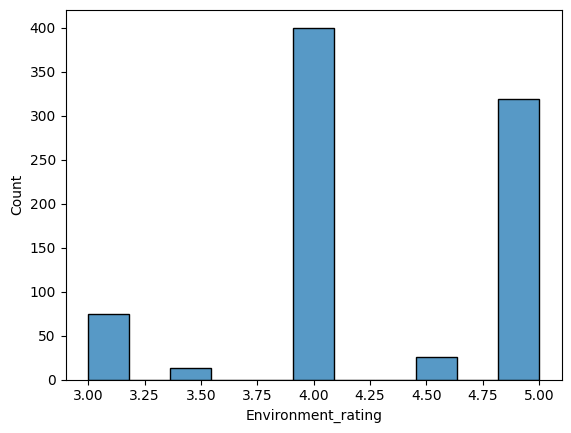

In [169]:
sns.histplot(df['Environment_rating'])

In [170]:
df['Lifestyle_rating'].value_counts()

Lifestyle_rating
4.0    483
5.0    312
4.5     27
3.0      8
3.5      3
Name: count, dtype: int64

<Axes: xlabel='Lifestyle_rating', ylabel='Count'>

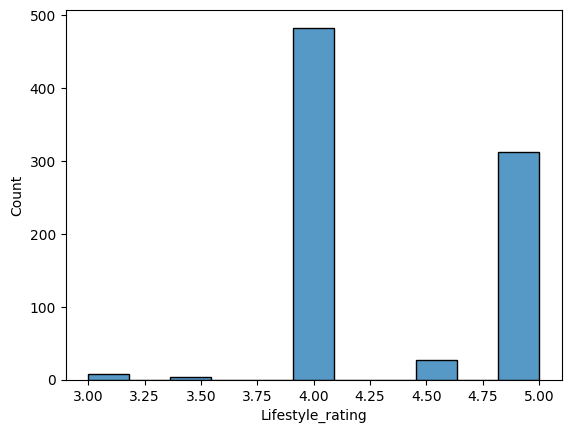

In [171]:
sns.histplot(df['Lifestyle_rating'])

similarly for connectivity ,count of houses whose ratings are 4 and 5 are more 

In [172]:
df['Connectivity_rating'].value_counts()

Connectivity_rating
5.0    520
4.0    234
3.5     40
4.5     35
3.0      4
Name: count, dtype: int64

<Axes: xlabel='Connectivity_rating', ylabel='Count'>

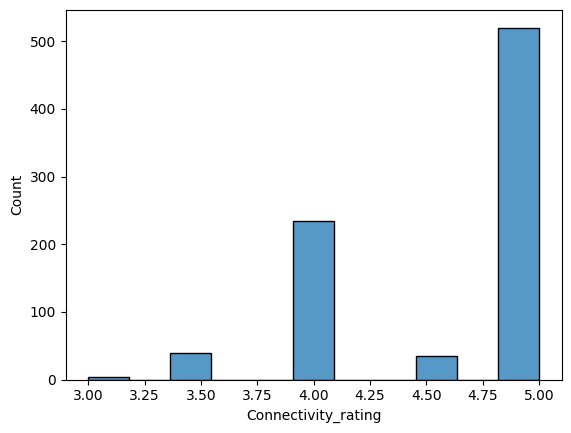

In [173]:
sns.histplot(df['Connectivity_rating'])

In [174]:
df['Safety_rating'].value_counts()

Safety_rating
4.0    502
5.0    231
4.5     74
3.0     21
3.5      5
Name: count, dtype: int64

<Axes: xlabel='Safety_rating', ylabel='Count'>

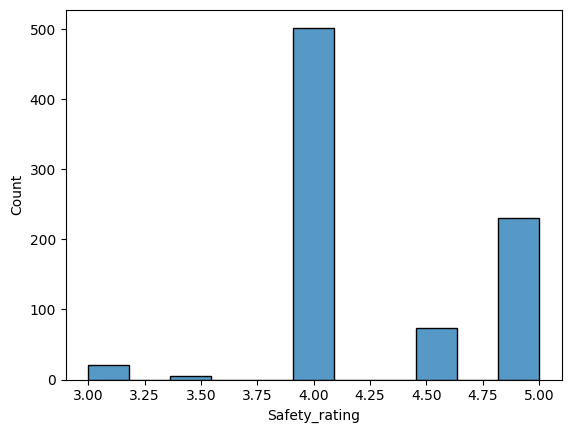

In [175]:
sns.histplot(df['Safety_rating'])

In [176]:
cols=['Connectivity_rating','Safety_rating','Lifestyle_rating','Environment_rating']

In [177]:
df[cols]=df[cols].fillna(df[cols].median())

In [178]:
df['Environment_rating'].isnull().sum()

np.int64(0)

In [179]:
df.columns

Index(['price', 'price_per_sqft', 'area', 'bedRoom', 'bathroom', 'balcony',
       'floorNum', 'facing', 'rating', 'location_target', 'is_premium_loc',
       'is_rare', 'effective_area_log', 'area_quality', 'carpet_efficiency',
       'carpet_eff_missing', 'construction_dens_missing', 'density_x_area',
       'society_encoded', 'society_israre', 'is_independent', 'servant_room',
       'pooja_room', 'study_room', 'store_room', 'Total_extra_rooms',
       'no_extra_room', 'agePossession_num', 'metro', 'near_hospital',
       'near_school', 'near_mall', 'near_bank', 'furnish_level',
       'amenity_count', 'zero_amenities', 'clean_rating', 'Environment_rating',
       'Lifestyle_rating', 'Connectivity_rating', 'Safety_rating'],
      dtype='object')

In [180]:
df.drop(['rating','clean_rating'],axis=1,inplace=True)

In [181]:
df.shape

(954, 39)

In [182]:
df.isnull().sum()

price                         18
price_per_sqft                18
area                          18
bedRoom                        0
bathroom                       0
balcony                        0
floorNum                       0
facing                       300
location_target                0
is_premium_loc                 0
is_rare                        0
effective_area_log             0
area_quality                   0
carpet_efficiency              0
carpet_eff_missing             0
construction_dens_missing      0
density_x_area                 0
society_encoded                0
society_israre                 0
is_independent                 0
servant_room                   0
pooja_room                     0
study_room                     0
store_room                     0
Total_extra_rooms              0
no_extra_room                  0
agePossession_num              0
metro                          0
near_hospital                  0
near_school                    0
near_mall 

# Facing

In [183]:
df['facing'].isnull().mean()*100 # % of data missing 

np.float64(31.446540880503143)

 missing % is high , hence i create a new col called 'unknown' ,just to keep my original data distributation const , and model learn from  missing data 

In [184]:
df['facing']=df['facing'].fillna('Unknown')

In [185]:
#flag to classify null facing catagories 
df['no_facing']=df['facing'].apply(lambda x : 1 if x =='Unknown' else 0)

In [186]:
df['no_facing'].value_counts() # about 303 rows dont have facing present 

no_facing
0    654
1    300
Name: count, dtype: int64

In [187]:
df['facing'].isnull().sum()

np.int64(0)

In [188]:
df['facing'].value_counts()

facing
Unknown       300
East          178
North-East    156
North         108
West           75
North-West     43
South-East     38
South          32
South-West     24
Name: count, dtype: int64

In [189]:
# Target encoding on facing
facing_price =df.groupby('facing')['price'].mean()
facing_dict = facing_price.to_dict()
df['facing_encoded'] = df['facing'].map(facing_dict)

In [190]:
df['facing_encoded'].value_counts()

facing_encoded
3.010340    300
5.760739    178
6.546948    156
5.942243    108
5.690000     75
5.635476     43
3.682500     38
3.795161     32
5.689167     24
Name: count, dtype: int64

In [191]:
df['facing_encoded'].corr(df['price'])

np.float64(0.30635521449381786)

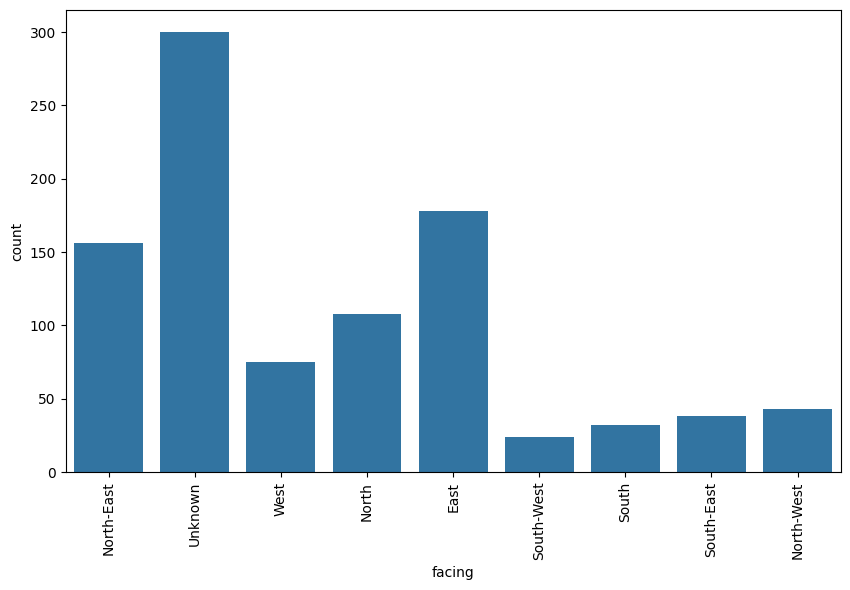

In [192]:
plt.figure(figsize=(10,6))
sns.countplot(x='facing',data=df)
plt.xticks(rotation=90)
plt.show()

In [193]:
df.drop(columns=['facing'],axis=1,inplace=True)

In [194]:
df.isnull().sum()

price                        18
price_per_sqft               18
area                         18
bedRoom                       0
bathroom                      0
balcony                       0
floorNum                      0
location_target               0
is_premium_loc                0
is_rare                       0
effective_area_log            0
area_quality                  0
carpet_efficiency             0
carpet_eff_missing            0
construction_dens_missing     0
density_x_area                0
society_encoded               0
society_israre                0
is_independent                0
servant_room                  0
pooja_room                    0
study_room                    0
store_room                    0
Total_extra_rooms             0
no_extra_room                 0
agePossession_num             0
metro                         0
near_hospital                 0
near_school                   0
near_mall                     0
near_bank                     0
furnish_

# Area

In [195]:
df['area'].value_counts()

area
3240.0    45
900.0     39
2700.0    36
1800.0    30
1350.0    21
          ..
1926.0     1
539.0      1
3323.0     1
8116.0     1
1341.0     1
Name: count, Length: 391, dtype: int64

<Axes: xlabel='area', ylabel='Density'>

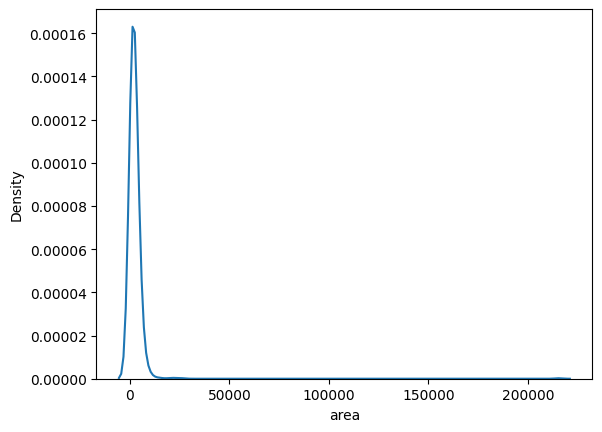

In [196]:
sns.kdeplot(df['area'])

In [197]:
df['area'].value_counts()

area
3240.0    45
900.0     39
2700.0    36
1800.0    30
1350.0    21
          ..
1926.0     1
539.0      1
3323.0     1
8116.0     1
1341.0     1
Name: count, Length: 391, dtype: int64

In [198]:
df['area'].skew() # heavy right skewed 

np.float64(26.77443487222058)

<Axes: >

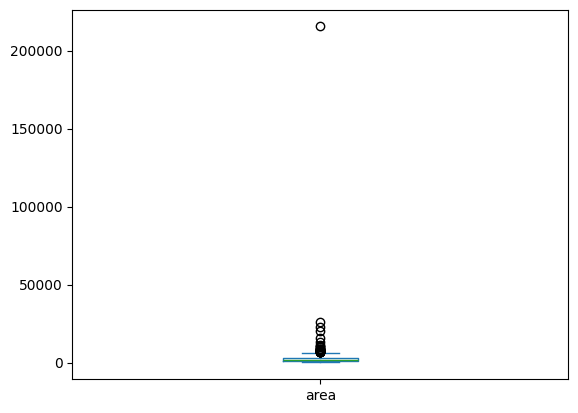

In [199]:
df['area'].plot.box()

In [200]:
#Handling outliers using IQR method 
q1 = df['area'].quantile(0.25)
q3 = df['area'].quantile(0.75)

IQR = q3 - q1

lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR

In [201]:
lower_limit

np.float64(-2394.375)

In [202]:
upper_limit

np.float64(6476.625)

In [203]:
df[(df['area']>upper_limit)|(df['area']<lower_limit)].shape # this are outliers 

(31, 40)

### capping 

In [204]:
df['area']=np.where(
    df['area']>upper_limit,
    upper_limit,
    np.where(
        df['area']<lower_limit,
        lower_limit,
        df['area']
    )

)

<Axes: xlabel='area', ylabel='Count'>

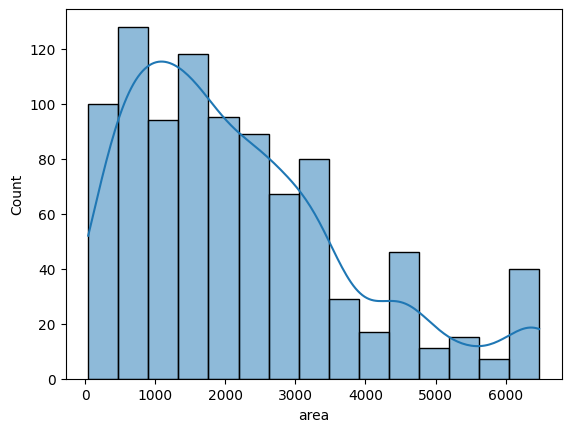

In [205]:
sns.histplot(df['area'],kde=True)

<Axes: ylabel='area'>

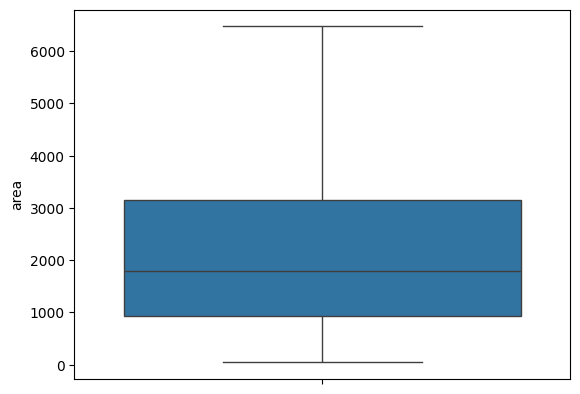

In [206]:
sns.boxplot(df['area'])

In [207]:
df['area']=df['area'].fillna(df['area'].median())

In [208]:
df['area'] = np.log1p(df['area'])

<Axes: xlabel='area', ylabel='Count'>

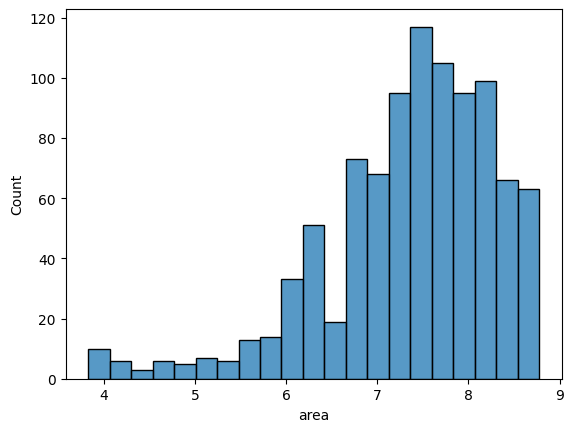

In [209]:
sns.histplot(df['area'])

In [210]:
df['area'].corr(df['price'])

np.float64(0.5765603385733012)

In [211]:
df.isnull().sum()

price                        18
price_per_sqft               18
area                          0
bedRoom                       0
bathroom                      0
balcony                       0
floorNum                      0
location_target               0
is_premium_loc                0
is_rare                       0
effective_area_log            0
area_quality                  0
carpet_efficiency             0
carpet_eff_missing            0
construction_dens_missing     0
density_x_area                0
society_encoded               0
society_israre                0
is_independent                0
servant_room                  0
pooja_room                    0
study_room                    0
store_room                    0
Total_extra_rooms             0
no_extra_room                 0
agePossession_num             0
metro                         0
near_hospital                 0
near_school                   0
near_mall                     0
near_bank                     0
furnish_

Droping price_per_sqft col because this may create "TARGET LEAKAGE" ,higher risk of overfitting the data 

In [212]:
df.drop(columns=['price_per_sqft'],axis=1,inplace=True)

<Axes: xlabel='price', ylabel='Count'>

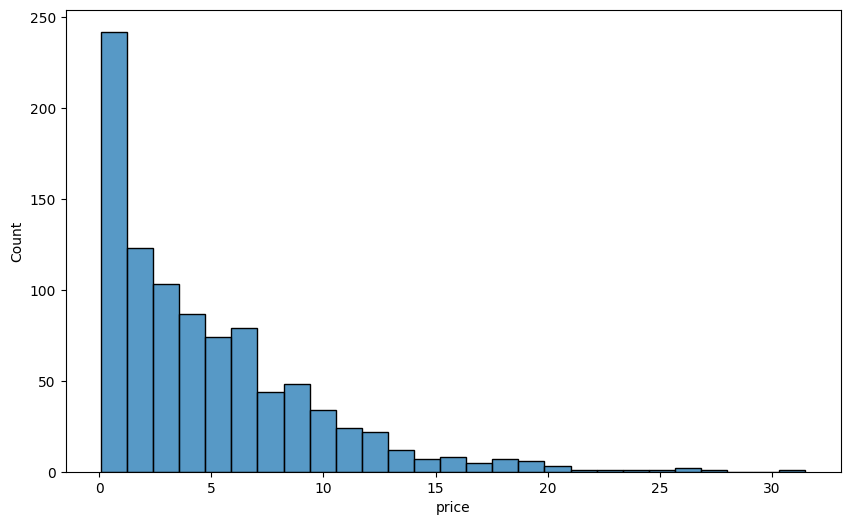

In [213]:
plt.figure(figsize=(10,6))
sns.histplot(x=df['price'],data=df)

In [214]:
df['price'].value_counts()

price
3.50     19
6.50     16
5.50     16
6.00     14
5.00     13
         ..
4.10      1
10.80     1
5.30      1
18.25     1
2.98      1
Name: count, Length: 291, dtype: int64

In [215]:
df['price'].skew()

np.float64(1.6479410227543752)

<Axes: ylabel='price'>

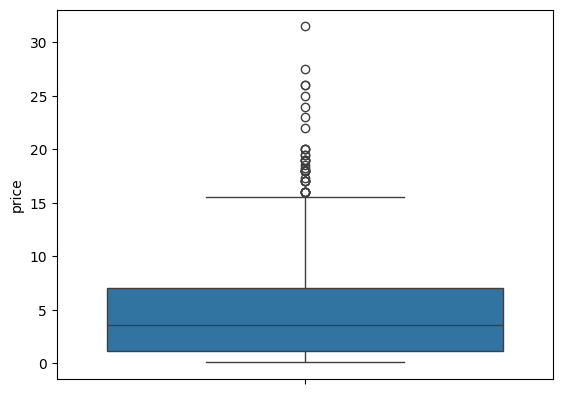

In [216]:
sns.boxplot(df['price']) # col contains outliers 

In [217]:
# IQR 
Q1=df['price'].quantile(0.25)
Q3=df['price'].quantile(0.75)
IQR =Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print(lower)
print(upper)

-7.562500000000001
15.7375


In [218]:
df[(df['price']>upper)|(df['price']<lower)].shape

(35, 39)

In [219]:
#capping
df['price']=np.where(
    df['price']>upper,
    upper,
    np.where(
        df['price']<lower,
        lower,
        df['price']
    )
)

<Axes: ylabel='price'>

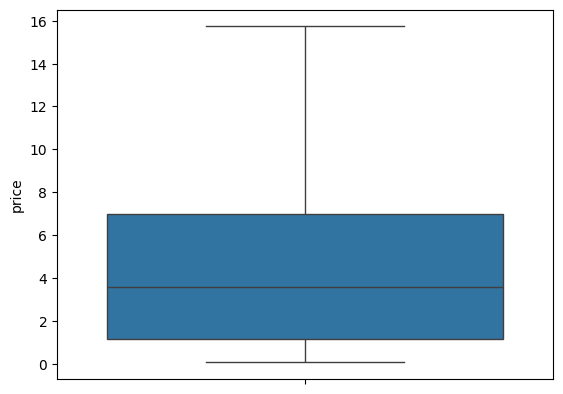

In [220]:
sns.boxplot(df['price'])

<Axes: xlabel='price', ylabel='Count'>

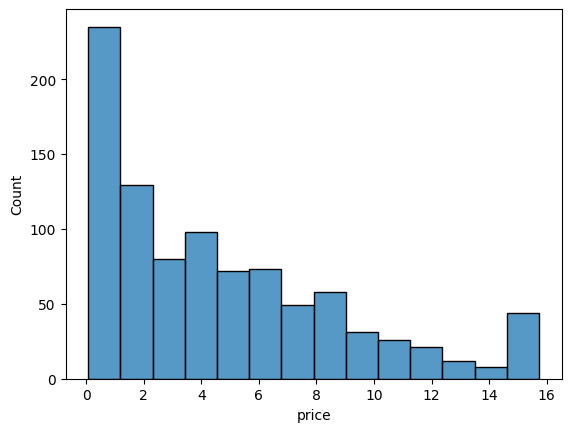

In [221]:
sns.histplot(df['price'])

In [222]:
df['price'].skew() # data is slight right skewed we use meadian to fill missing values 

np.float64(1.030329695076072)

In [223]:
df['price']=df['price'].fillna(df['price'].median())

In [224]:
df['price']=np.log1p(df['price']) #transform

<Axes: xlabel='price', ylabel='Count'>

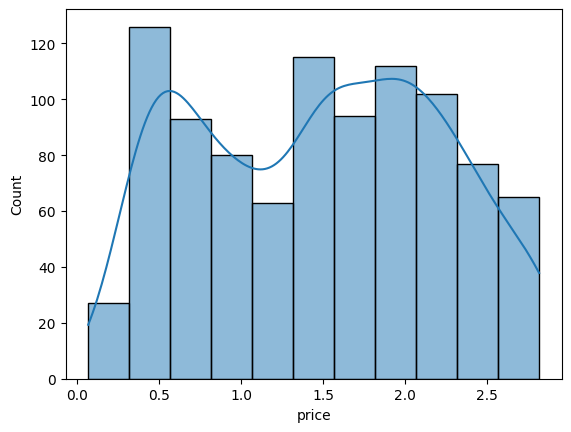

In [225]:
sns.histplot(df['price'],kde=True)

In [226]:
df.isnull().sum()

price                        0
area                         0
bedRoom                      0
bathroom                     0
balcony                      0
floorNum                     0
location_target              0
is_premium_loc               0
is_rare                      0
effective_area_log           0
area_quality                 0
carpet_efficiency            0
carpet_eff_missing           0
construction_dens_missing    0
density_x_area               0
society_encoded              0
society_israre               0
is_independent               0
servant_room                 0
pooja_room                   0
study_room                   0
store_room                   0
Total_extra_rooms            0
no_extra_room                0
agePossession_num            0
metro                        0
near_hospital                0
near_school                  0
near_mall                    0
near_bank                    0
furnish_level                0
amenity_count                0
zero_ame

<Axes: xlabel='bathroom', ylabel='Count'>

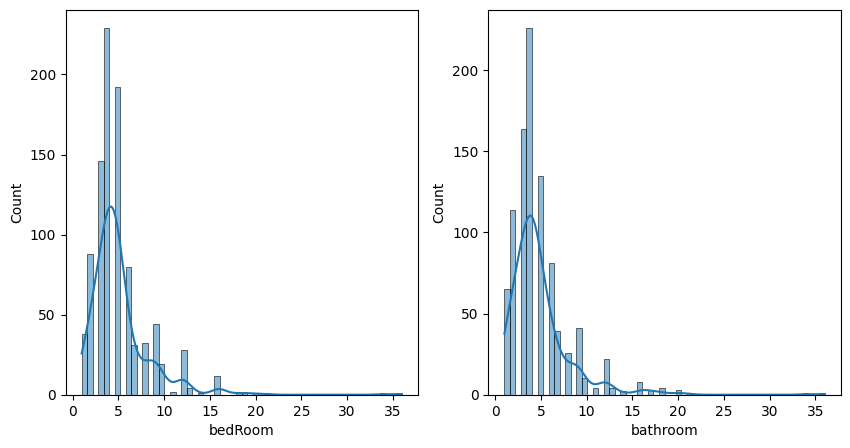

In [227]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(df['bedRoom'],kde=True)
plt.subplot(1,2,2)
sns.histplot(df['bathroom'],kde=True)

Bedroom

In [228]:
df['bedRoom'].value_counts()

bedRoom
4     229
5     192
3     146
2      88
6      80
9      44
1      38
8      32
7      31
12     28
10     19
16     12
13      4
11      2
19      2
18      2
21      1
20      1
36      1
34      1
14      1
Name: count, dtype: int64

<Axes: ylabel='bedRoom'>

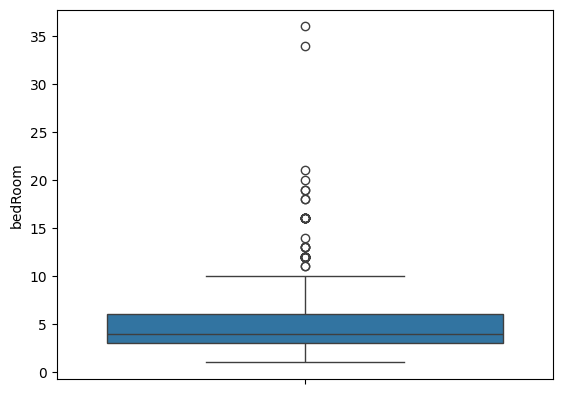

In [229]:
sns.boxplot(df['bedRoom'])

In [230]:
df['bedRoom'].skew() #right skew 

np.float64(2.958996469515578)

In [231]:
Q1=df['bedRoom'].quantile(0.25)
Q3=df['bedRoom'].quantile(0.75)
IQR =Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print(lower)
print(upper)

-1.5
10.5


In [232]:
df[(df['bedRoom']>upper)|(df['bedRoom']<lower)].shape

(55, 39)

In [233]:
df['bedRoom']=np.where(
    df['bedRoom']>upper,
    upper,
    np.where(
        df['bedRoom']<lower,
        lower,
        df['bedRoom']
    )
)

<Axes: ylabel='bedRoom'>

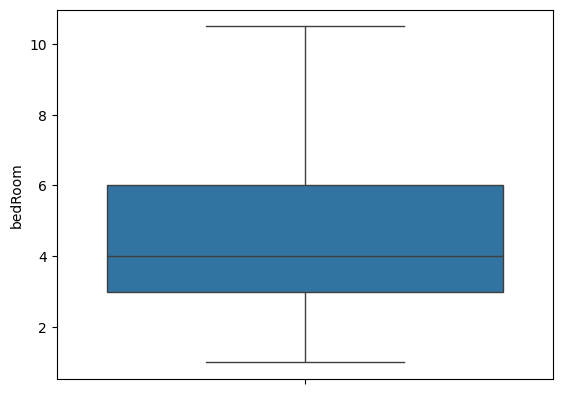

In [234]:
sns.boxplot(df['bedRoom'])

<Axes: xlabel='bedRoom', ylabel='Count'>

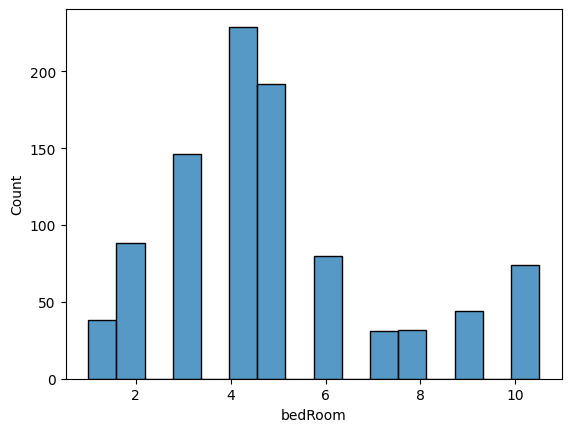

In [235]:
sns.histplot(df['bedRoom'])

In [236]:
df['bedRoom'].value_counts()

bedRoom
4.0     229
5.0     192
3.0     146
2.0      88
6.0      80
10.5     55
9.0      44
1.0      38
8.0      32
7.0      31
10.0     19
Name: count, dtype: int64

In [237]:
# lux home bedrooms signal !
df['lux_home_bedrooms']=df['bedRoom'].apply(lambda x : 1 if x > 5 else 0)

In [238]:
df['lux_home_bedrooms'].value_counts()

lux_home_bedrooms
0    693
1    261
Name: count, dtype: int64

In [239]:
df['bedRoom'].corr(df['price'])

np.float64(0.3808711528057515)

In [240]:
df['lux_home_bedrooms'].corr(df['price'])

np.float64(0.20383576241430001)

In [241]:
df['bathroom'].value_counts()

bathroom
4     226
3     164
5     135
2     114
6      81
1      65
9      41
7      39
8      26
12     22
10     10
16      8
13      4
18      4
11      4
17      3
20      3
14      2
21      1
34      1
36      1
Name: count, dtype: int64

In [242]:
df['bathroom'].skew()

np.float64(2.9799395092561602)

<Axes: ylabel='bathroom'>

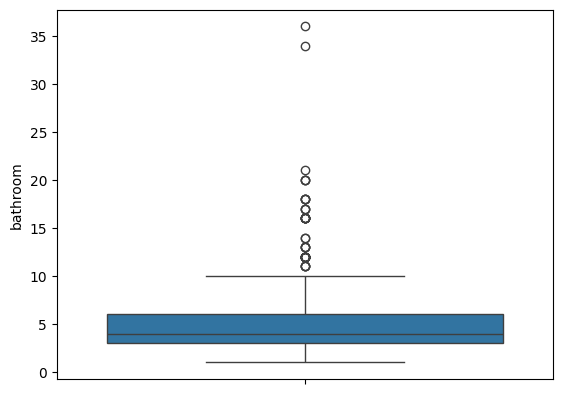

In [243]:
sns.boxplot(df['bathroom'])

In [244]:
Q1=df['bathroom'].quantile(0.25)
Q3=df['bathroom'].quantile(0.75)
IQR =Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print(lower)
print(upper)

-1.5
10.5


In [245]:
df[(df['bathroom']>upper)|(df['bathroom']<lower)].shape

(53, 40)

In [246]:
df['bathroom']=np.where(
    df['bathroom']>upper,
    upper,
    np.where(
        df['bathroom']<lower,
        lower,
        df['bathroom']
    )
)

<Axes: xlabel='bathroom', ylabel='Count'>

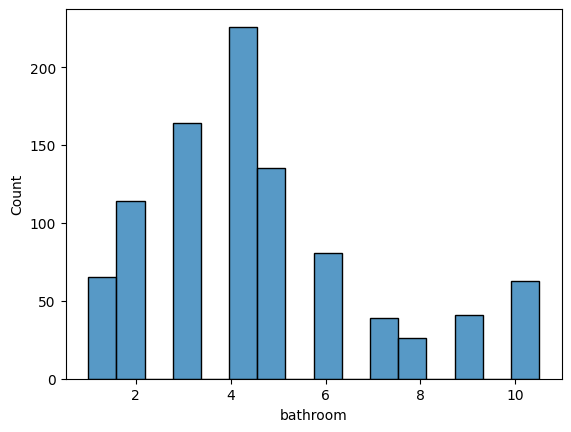

In [247]:
sns.histplot(df['bathroom'])

In [248]:
df['lux_home_bathrooms']=(df['bathroom']>6).astype(int)

In [249]:
df['lux_home_bathrooms'].value_counts()

lux_home_bathrooms
0    785
1    169
Name: count, dtype: int64

In [250]:
df.columns

Index(['price', 'area', 'bedRoom', 'bathroom', 'balcony', 'floorNum',
       'location_target', 'is_premium_loc', 'is_rare', 'effective_area_log',
       'area_quality', 'carpet_efficiency', 'carpet_eff_missing',
       'construction_dens_missing', 'density_x_area', 'society_encoded',
       'society_israre', 'is_independent', 'servant_room', 'pooja_room',
       'study_room', 'store_room', 'Total_extra_rooms', 'no_extra_room',
       'agePossession_num', 'metro', 'near_hospital', 'near_school',
       'near_mall', 'near_bank', 'furnish_level', 'amenity_count',
       'zero_amenities', 'Environment_rating', 'Lifestyle_rating',
       'Connectivity_rating', 'Safety_rating', 'no_facing', 'facing_encoded',
       'lux_home_bedrooms', 'lux_home_bathrooms'],
      dtype='object')

# new Feature Creation 

In [251]:
df['bedroom_density']=df['bedRoom']/df['area']

In [252]:
df['lifestyle_score']=(
    df['near_hospital']+
    df['near_bank']+
    df['Connectivity_rating']+
    df['Safety_rating']
)

In [253]:
df['bed_loc_interaction'] = df['bedRoom'] * df['location_target'] # eg ( 3BHK in premium area ≠ 3BHK in normal area )

In [254]:
df['area_bed_loc'] = df['area'] * df['bedRoom'] * df['location_target']

# model training

In [255]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [256]:
X = df.drop(columns=['price'],axis=1)
Y=df['price']

In [257]:
Y

0      1.832581
1      1.902108
2      1.131402
3      1.791759
4      1.386294
         ...   
959    1.871802
960    1.658228
961    1.704748
962    1.446919
963    1.526056
Name: price, Length: 954, dtype: float64

In [258]:
X_train , X_test , y_train , y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [259]:
X_train.shape

(763, 44)

In [260]:
X_test.shape

(191, 44)

In [261]:
y_test.shape

(191,)

In [262]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder ,StandardScaler

data --> onehot,ordinal encoder ---> scale --> pca--->model train ---> r2 score

In [263]:
X_train.columns

Index(['area', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'location_target',
       'is_premium_loc', 'is_rare', 'effective_area_log', 'area_quality',
       'carpet_efficiency', 'carpet_eff_missing', 'construction_dens_missing',
       'density_x_area', 'society_encoded', 'society_israre', 'is_independent',
       'servant_room', 'pooja_room', 'study_room', 'store_room',
       'Total_extra_rooms', 'no_extra_room', 'agePossession_num', 'metro',
       'near_hospital', 'near_school', 'near_mall', 'near_bank',
       'furnish_level', 'amenity_count', 'zero_amenities',
       'Environment_rating', 'Lifestyle_rating', 'Connectivity_rating',
       'Safety_rating', 'no_facing', 'facing_encoded', 'lux_home_bedrooms',
       'lux_home_bathrooms', 'bedroom_density', 'lifestyle_score',
       'bed_loc_interaction', 'area_bed_loc'],
      dtype='object')

In [264]:
# Applying col transformation , Ordinal Encoding on furnished & scaling num cols  
num_cols=[
    'area',
    'bedRoom',
    'bathroom',
    'balcony',
    'location_target',
    'agePossession_num',
    'amenity_count',
    'Environment_rating',
    'Lifestyle_rating',
    'Connectivity_rating',
    'Safety_rating',
    'facing_encoded',
    'density_x_area'
]

trf1=ColumnTransformer(
    transformers=[
        ('ordinal_furnished',OrdinalEncoder(categories=[['Unfurnished','Semi-furnished','Furnished']]),['furnish_level']),
        ('scaling',StandardScaler(),num_cols)
    ],
    remainder='passthrough'
)


linear reg

In [ ]:
# from sklearn.linear_model import LinearRegression
# from sklearn.pipeline import Pipeline

# trf2 = LinearRegression()

# pipeline=Pipeline([
#     ('trf1',trf1),
#     ('trf2',trf2)
# ])
# pipeline.fit(X_train,y_train)

,steps,"[('trf1', ...), ('trf2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal_furnished', ...), ('scaling', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# y_pred = pipeline.predict(X_test)
# from sklearn.metrics import r2_score
# r2_test = r2_score(y_test,y_pred)
# print("r2_test",r2_test)
# r2_train = r2_score(y_train,pipeline.predict(X_train))
# print("r2_train",r2_train)

r2_test 0.7835416153549313
r2_train 0.8126812123613445


Ridge

In [ ]:
#RIDGE
# from sklearn.linear_model import Ridge
# from sklearn.pipeline import Pipeline

# trf2 = Ridge(alpha=0.05,max_iter=500,solver='sparse_cg')

# pipeline=Pipeline([
#     ('trf1',trf1),
#     ('trf2',trf2)
# ])
# pipeline.fit(X_train,y_train)

# y_pred = pipeline.predict(X_test)
# y_pred1 = pipeline.predict(X_train)
# print("r2_score on test data: ",r2_score(y_test,y_pred))
# print("r2_score on training data: ",r2_score(y_train,y_pred1))

r2_score on test data:  0.7835416153549313
r2_score on training data:  0.8126812123613445


In [981]:
# #SGD REGRESSOR
# from sklearn.linear_model import SGDRegressor
# from sklearn.pipeline import Pipeline

# trf3 = SGDRegressor(penalty='l2',max_iter=500,learning_rate='constant',eta0=0.005,alpha=0.05)

# pipeline=Pipeline([
#     ('trf1',trf1),
#     ('trf3',trf3)
# ])

Decision Tree

In [ ]:
# Decision Tree
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.metrics import r2_score

# # create model
# trf2 = DecisionTreeRegressor(
#     max_depth=10,
#     min_samples_split=10,
#     min_samples_leaf=5)

# pipeline=Pipeline([
#     ('trf1',trf1),
#     ('trf2',trf2)
# ])

# pipeline.fit(X_train,y_train)

# # prediction
# y_pred = pipeline.predict(X_test)

# # evaluation
# print("Decision Tree R2 Score on test data :", r2_score(y_test, y_pred))
# print("Decision Tree R2 Score on training data :", r2_score(y_train,pipeline.predict(X_train)))

Decision Tree R2 Score on test data : 0.7527380150148418
Decision Tree R2 Score on training data : 0.9284370441024219


Random Forest

In [275]:
# random forest 
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

trf2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
pipeline=Pipeline([
    ('trf1',trf1),
    ('trf2',trf2)
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Random Forest R2 on testing data : ", r2_score(y_test, y_pred))
print("Random Forest R2 on training data : ",r2_score(y_train,pipeline.predict(X_train)))

Random Forest R2 on testing data :  0.8296840484086261
Random Forest R2 on training data :  0.9784987626703335


In [266]:
trf2.feature_importances_

array([2.83200628e-03, 2.10813711e-01, 3.21075838e-03, 7.66727408e-03,
       2.99088516e-03, 4.74507101e-02, 3.85211263e-03, 1.96178825e-02,
       3.13146890e-03, 2.99129809e-03, 1.43240410e-03, 2.07060565e-03,
       6.33972766e-03, 1.08872079e-02, 5.88392740e-03, 1.70980566e-03,
       1.15008100e-03, 1.44277947e-02, 1.67738147e-03, 2.22478101e-03,
       3.08727943e-04, 7.80243471e-04, 2.32446277e-03, 1.11401233e-03,
       1.15121684e-03, 3.45490492e-03, 9.67921886e-04, 6.82980647e-04,
       4.07517378e-04, 6.98431437e-03, 5.34849380e-04, 1.86003229e-03,
       9.71066317e-04, 1.36605086e-03, 1.66808629e-03, 1.36470431e-03,
       1.89010984e-03, 5.19828087e-04, 2.45010658e-04, 3.02052935e-04,
       1.27279609e-02, 5.79114689e-03, 2.83881276e-02, 5.71832847e-01])

In [273]:
X_train.shape

(763, 44)

In [ ]:
import pandas as pd

feature_names = X_train.columns

importances = trf2.feature_importances_

#  Create DataFrame
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Step 4: Sort (important)
feat_imp = feat_imp.sort_values(by="importance", ascending=False)

print(feat_imp)

                      feature  importance
43               area_bed_loc    0.571833
1                     bedRoom    0.210814
5             location_target    0.047451
42        bed_loc_interaction    0.028388
7                     is_rare    0.019618
17               servant_room    0.014428
40            bedroom_density    0.012728
13             density_x_area    0.010887
3                     balcony    0.007667
29              furnish_level    0.006984
12  construction_dens_missing    0.006340
14            society_encoded    0.005884
41            lifestyle_score    0.005791
6              is_premium_loc    0.003852
25              near_hospital    0.003455
2                    bathroom    0.003211
8          effective_area_log    0.003131
9                area_quality    0.002991
4                    floorNum    0.002991
0                        area    0.002832
22              no_extra_room    0.002324
19                 study_room    0.002225
11         carpet_eff_missing    0

# cross val score 

In [274]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross validation
cv_scores = cross_val_score(
    pipeline, 
    X_train,   # use full dataset (not just train split)
    y_train, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

print("Cross Validation R2 Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross Validation R2 Scores: [0.83716921 0.85822663 0.84575866 0.83470125 0.84755171]
Mean CV R2: 0.8446814914973328
Std Dev: 0.00835355063832585


In [999]:
import pickle
pickle.dump(pipeline, open('model.pkl', 'wb'))